In [1]:
# %% Libraries
import os
import scanpy as sc
#import scvi
import numpy as np
from pathlib import Path
import pandas as pd
import anndata as ad
import rapids_singlecell as rsc

sc.logging.print_header()


# %% Setting Paths
MAIN_DIR_NAME = "cosmx_gray"
MAIN_DIR = next(p for p in Path.cwd().parents if (p / MAIN_DIR_NAME).exists()) / MAIN_DIR_NAME
os.chdir(MAIN_DIR)

# %% Setting Seed
SEED_VALUE = 42
# set NumPy RNG for consistency
np.random.seed(SEED_VALUE)

# %% object versions
CUR_OBJ_V = 'v8'
CUR_OBJ_PATH = MAIN_DIR / 'data' / 'comb' / 'h5ad' / f'comb_{CUR_OBJ_V}.h5ad'
NEW_OBJ_V = 'v9'
NEW_OBJ_PATH = MAIN_DIR / 'data' / 'comb' / 'h5ad' / f'comb_{NEW_OBJ_V}.h5ad'


# %% Load the unintegrated object
comb = sc.read_h5ad(CUR_OBJ_PATH)

/mnt/data/project0062/.conda/envs/rsc_25.12/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Use the tools that have for spatial analysis in teh squidpy tutorial for nantring data

In [2]:
from pathlib import Path

import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import scanpy as sc
import squidpy as sq

sc.logging.print_header()

/mnt/data/project0062/.conda/envs/rsc_25.12/lib/python3.13/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/mnt/data/project0062/.conda/envs/rsc_25.12/lib/python3.13/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/mnt/data/project0062/.conda/envs/rsc_25.12/lib/python3.13/site-packages/spatialdata/_core/query/relational_query.py:530: FutureWarning: functools.partial will be a method descriptor in future Python versions;

Package,Version
scanpy,1.11.5
numpy,2.2.6
pandas,2.3.3
anndata,0.12.7
rapids_singlecell,0.13.5
matplotlib,3.10.8
seaborn,0.13.2
squidpy,1.7.0
Component,Info
Python,"3.13.11 | packaged by conda-forge | (main, Dec 6 2025, 11:24:03) [GCC 14.3.0]"


In [3]:
import os

os.environ["NUMBA_NUM_THREADS"] = "64"
os.environ["OMP_NUM_THREADS"] = "64"
os.environ["MKL_NUM_THREADS"] = "64"


## Calculate quality control metrics

In [4]:
comb.var["NegPrb"] = comb.var_names.str.startswith("NegPrb")
sc.pp.calculate_qc_metrics(comb, qc_vars=["NegPrb"], inplace=True)

In [6]:
import pandas as pd

pd.set_option("display.max_columns", None)

In [7]:
comb.obs["total_counts_NegPrb"].sum() / comb.obs["total_counts"].sum() * 100

np.float32(0.0)

In [15]:
comb

AnnData object with n_obs × n_vars = 1326786 × 6175
    obs: 'fov', 'Area', 'AspectRatio', 'Width', 'Height', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD68', 'Max.CD68', 'Mean.Membrane', 'Max.Membrane', 'Mean.CD45', 'Max.CD45', 'Mean.DAPI', 'Max.DAPI', 'SplitRatioToLocal', 'NucArea', 'NucAspectRatio', 'Circularity', 'Eccentricity', 'Perimeter', 'Solidity', 'assay_type', 'version', 'Run_Tissue_name', 'Panel', 'cellSegmentationSetId', 'cellSegmentationSetName', 'slide_ID', 'CenterX_global_px', 'CenterY_global_px', 'unassignedTranscripts', 'median_RNA', 'RNA_quantile_0.75', 'RNA_quantile_0.8', 'RNA_quantile_0.85', 'RNA_quantile_0.9', 'RNA_quantile_0.95', 'RNA_quantile_0.99', 'nCount_RNA', 'nFeature_RNA', 'median_negprobes', 'negprobes_quantile_0.75', 'negprobes_quantile_0.8', 'negprobes_quantile_0.85', 'negprobes_quantile_0.9', 'negprobes_quantile_0.95', 'negprobes_quantile_0.99', 'nCount_negprobes', 'nFeature_negprobes', 'median_falsecode', 'falsecode_quantile_0.75', 'falsecode_quantile_0.8', 'f

## Computation of spatial neighbors graphs

/mnt/data/project0062/.conda/envs/rsc_25.12/lib/python3.13/site-packages/squidpy/pl/_color_utils.py:28: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  target.uns[color_key] = source.uns[color_key]
/mnt/data/project0062/.conda/envs/rsc_25.12/lib/python3.13/site-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


/mnt/data/project0062/.conda/envs/rsc_25.12/lib/python3.13/site-packages/squidpy/pl/_color_utils.py:28: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  target.uns[color_key] = source.uns[color_key]
/mnt/data/project0062/.conda/envs/rsc_25.12/lib/python3.13/site-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


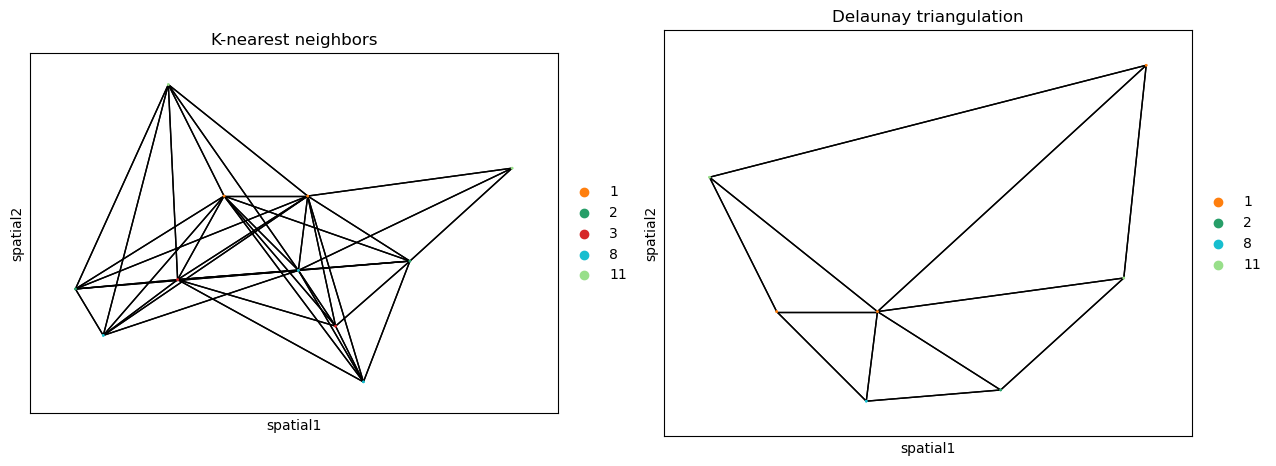

In [29]:
fig, ax = plt.subplots(1, 2, figsize=(15, 15))
sq.gr.spatial_neighbors(
    comb,
    n_neighs=10,
    library_key="sample_name",
    coord_type="generic",
)

_, idx = comb.obsp["spatial_connectivities"][420, :].nonzero()
idx = np.append(idx, 420)
sq.pl.spatial_scatter(
    comb[idx, :],
    library_id=None,
    color="leiden_resolvi",
    connectivity_key="spatial_connectivities",
    size=3,
    edges_width=1,
    edges_color="black",
    img=False,
    shape=None,
    title="K-nearest neighbors",
    ax=ax[0],
)

sq.gr.spatial_neighbors(
    comb,
    n_neighs=10,
    coord_type="generic",
    library_key="sample_name",
    delaunay=True,
)
_, idx = comb.obsp["spatial_connectivities"][420, :].nonzero()
idx = np.append(idx, 420)

sq.pl.spatial_scatter(
    comb[idx, :],
    library_id=None,
    color="leiden_resolvi",
    connectivity_key="spatial_connectivities",
    size=3,
    edges_width=1,
    edges_color="black",
    img=False,
    shape=None,
    title="Delaunay triangulation",
    ax=ax[1],
)

In [30]:
comb.obsp["spatial_connectivities"]

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 7923434 stored elements and shape (1326786, 1326786)>

In [31]:
comb.obsp["spatial_distances"]

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 7923434 stored elements and shape (1326786, 1326786)>

In [ ]:
sq.gr.spatial_neighbors(
    comb,
    radius=30,
    coord_type="generic",
    library_key="sample_name",
)

_, idx = comb.obsp["spatial_connectivities"][420, :].nonzero()
idx = np.append(idx, 420)

/mnt/data/project0062/.conda/envs/rsc_25.12/lib/python3.13/site-packages/squidpy/pl/_color_utils.py:28: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  target.uns[color_key] = source.uns[color_key]
/mnt/data/project0062/.conda/envs/rsc_25.12/lib/python3.13/site-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


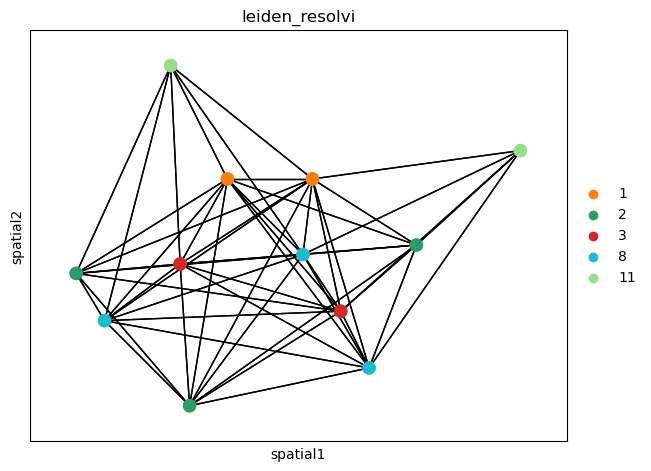

In [37]:
sq.pl.spatial_scatter(
    comb[idx, :],
    library_id=None,
    color="leiden_resolvi",
    connectivity_key="spatial_connectivities",
    size=300,
    edges_width=1,
    edges_color="black",
    img=False,
    shape=None,
)

## Compute centrality scores

In [38]:
adata_spatial_neighbor = sq.gr.spatial_neighbors(
    comb, coord_type="generic", delaunay=True, library_key="sample_name"
)

In [42]:
NUMBA_NUM_THREADS = 64
os.environ["NUMBA_NUM_THREADS"] = str(NUMBA_NUM_THREADS)
sq.gr.centrality_scores(
    comb, 
    cluster_key="leiden_resolvi", 
    n_jobs=NUMBA_NUM_THREADS,
    show_progress_bar=True
) 

  0%|          | 0/20 [00:00<?, ?/s]/mnt/data/project0062/.conda/envs/rsc_25.12/lib/python3.13/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/mnt/data/project0062/.conda/envs/rsc_25.12/lib/python3.13/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/mnt/data/project0062/.conda/envs/rsc_25.12/lib/python3.13/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated

2026-01-15 13:10:45 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-15 13:10:45 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-15 13:10:45 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-15 13:10:45 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-15 13:10:45 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If 

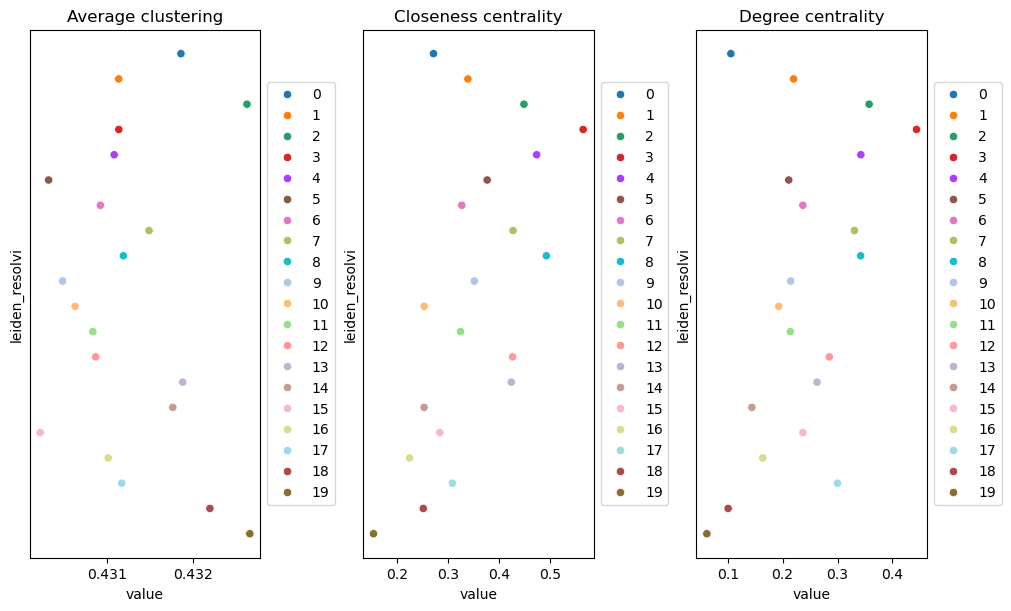

In [43]:
sq.pl.centrality_scores(comb, cluster_key="leiden_resolvi", figsize=(10, 6))

## Compute co-ocurrence probability

In [44]:
comb.obs['fov_name'].unique()

['SLIDE03_1', 'SLIDE03_2', 'SLIDE03_3', 'SLIDE03_4', 'SLIDE03_5', ..., 'SLIDE04_188', 'SLIDE04_189', 'SLIDE04_190', 'SLIDE04_191', 'SLIDE04_192']
Length: 1052
Categories (1052, object): ['SLIDE01_1', 'SLIDE01_2', 'SLIDE01_3', 'SLIDE01_4', ..., 'SLIDE04_220', 'SLIDE04_221', 'SLIDE04_222', 'SLIDE04_223']

In [4]:
adata_subset = comb[comb.obs.fov_name == "SLIDE01_1"].copy()

In [6]:

sq.gr.co_occurrence(
    adata_subset,
    cluster_key="leiden_resolvi",
    n_jobs=64,
)
sq.pl.co_occurrence(
    adata_subset,
    cluster_key="leiden_resolvi",
    clusters="3",
    n_jobs=NUMBA_NUM_THREADS,
)


sq.pl.spatial_segment(
    adata_subset,
    shape="hex",
    color="leiden_resolvi",
    library_id="SLIDE01_1",
    library_key="fov",
    seg_cell_id="cell_ID",
    img=False,
    size=60,
)

RuntimeError: Cannot set NUMBA_NUM_THREADS to a different value once the threads have been launched (currently have 64, trying to set 128)